In [1]:
import os
import hashlib
from pathlib import Path
import importlib
import hsaids
importlib.reload(hsaids)  # Reload module to get latest changes
from hsaids import HSAIDS
from collections import defaultdict
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import time
%matplotlib inline

# Configuration: Set the directory path to scan for duplicate files
SCAN_PATH = "/Users/soneyeoluwasina/Downloads/Skin"  # Change this to the directory you want to scan
# Example: SCAN_PATH = "/Users/username/Documents" or SCAN_PATH = "C:\\Users\\username\\Documents"

print(f"🔍 Scanning directory: {os.path.abspath(SCAN_PATH)}")
print("🚀 Using HSAIDS (Hierarchical Sketch Assisted Inline De-duplication Scheme)")

🔍 Scanning directory: /Users/soneyeoluwasina/Downloads/Skin
🚀 Using HSAIDS (Hierarchical Sketch Assisted Inline De-duplication Scheme)


In [2]:

# Function to hash file contents
def hash_file(file_path):
    """
    Generate MD5 hash of file contents.
    Handles binary and text files safely.
    """
    hash_md5 = hashlib.md5()
    try:
        with open(file_path, "rb") as f:
            # Read file in chunks to handle large files efficiently
            for chunk in iter(lambda: f.read(4096), b""):
                hash_md5.update(chunk)
        return hash_md5.hexdigest()
    except (IOError, OSError, PermissionError) as e:
        print(f"⚠️  Error reading {file_path}: {e}")
        return None

# Function to get all files in directory (recursively scans all subdirectories)
def get_all_files(directory):
    """
    Recursively get all files in a directory and all subdirectories.
    os.walk() automatically traverses all subdirectories recursively.
    Returns list of file paths.
    """
    files = []
    directories_scanned = 0
    
    # Ensure directory path is absolute
    directory = os.path.abspath(directory)
    print(f"📂 Starting recursive scan from: {directory}")
    
    # os.walk() recursively traverses all subdirectories
    for root, dirs, filenames in os.walk(directory):
        directories_scanned += 1
        
        # Skip hidden directories (optional - remove if you want to include them)
        # Modifying dirs in-place prevents os.walk from descending into them
        dirs[:] = [d for d in dirs if not d.startswith('.')]
        
        for filename in filenames:
            # Skip hidden files (optional - remove if you want to include them)
            if not filename.startswith('.'):
                file_path = os.path.join(root, filename)
                # Only add if it's actually a file (not a directory or symlink to directory)
                if os.path.isfile(file_path):
                    files.append(file_path)
    
    print(f"✅ Scanned {directories_scanned} directories recursively")
    return files

# Get all files (recursively from all subdirectories)
all_files = get_all_files(SCAN_PATH)
print(f"📁 Found {len(all_files)} files to process (from all subdirectories)")

📂 Starting recursive scan from: /Users/soneyeoluwasina/Downloads/Skin
✅ Scanned 21 directories recursively
📁 Found 2357 files to process (from all subdirectories)


In [3]:

# Initialize HSAIDS (Enhanced system with all features)
hsaids = HSAIDS(
    hot_bloom_size=10000,
    hot_cms_width=5000,
    cold_bloom_size=100000,
    cold_cms_width=20000,
    threshold=2,
    promotion_threshold=5,
    merge_frequency=500
)

# Dictionary to track files by their hash
# Key: file hash, Value: list of file paths with that hash
file_hash_map = defaultdict(list)

print("🔄 Processing files with HSAIDS...")
print("   Features: Frequency-sensitive BF, Bayesian optimization, Container grouping")

🔄 Processing files with HSAIDS...
   Features: Frequency-sensitive BF, Bayesian optimization, Container grouping


In [4]:

# Process each file with timing measurements
duplicate_files = []  # List of (file_path, hash, object_id, metadata) for duplicates
unique_files = []      # List of (file_path, hash, object_id, metadata) for unique files

# Timing data structures
timing_data = []  # List of (file_index, time_per_file, cumulative_time, file_size)
total_start_time = time.time()
gc_start_time = None
gc_end_time = None

for i, file_path in enumerate(all_files, 1):
    file_start_time = time.time()
    
    # Hash the file contents
    file_hash = hash_file(file_path)
    
    if file_hash is None:
        continue  # Skip files that couldn't be read
    
    # Track file by hash
    file_hash_map[file_hash].append(file_path)
    
    # Prepare metadata
    try:
        file_size = os.path.getsize(file_path)
        metadata = {
            'file_path': file_path,
            'file_size': file_size,
            'file_name': os.path.basename(file_path)
        }
    except OSError:
        file_size = 0
        metadata = {'file_path': file_path, 'file_name': os.path.basename(file_path)}
    
    # Check with HSAIDS (returns dictionary with status and metadata)
    result = hsaids.insert(file_hash, metadata)
    
    file_end_time = time.time()
    file_processing_time = file_end_time - file_start_time
    cumulative_time = file_end_time - total_start_time
    
    # Store timing data
    timing_data.append({
        'file_index': i,
        'file_path': file_path,
        'time_per_file': file_processing_time,
        'cumulative_time': cumulative_time,
        'file_size_mb': file_size / (1024 * 1024) if file_size > 0 else 0
    })
    
    if result["status"] == "duplicate":
        duplicate_files.append((
            file_path, 
            file_hash,
            result.get("object_id"),
            result.get("duplicate_objects", []),
            result.get("frequency", 0),
            result.get("layer", "unknown")
        ))
    else:
        unique_files.append((
            file_path,
            file_hash,
            result.get("object_id"),
            result.get("group_id"),
            result.get("frequency", 0)
        ))
    
    # Progress indicator with HSAIDS stats
    if i % 100 == 0:
        stats = hsaids.get_statistics()
        avg_time = cumulative_time / i
        files_per_sec = i / cumulative_time if cumulative_time > 0 else 0
        print(f"  Processed {i}/{len(all_files)} files... "
              f"(Confidence: {stats['bayesian_confidence']:.2f}, "
              f"Groups: {stats['container_groups']}, "
              f"Speed: {files_per_sec:.1f} files/sec)")

processing_end_time = time.time()
total_processing_time = processing_end_time - total_start_time

print(f"✅ Processing complete!")
print(f"   Unique files: {len(unique_files)}")
print(f"   Duplicate files: {len(duplicate_files)}")
print(f"   Total processing time: {total_processing_time:.2f} seconds ({total_processing_time/60:.2f} minutes)")
print(f"   Average time per file: {total_processing_time/len(all_files)*1000:.2f} ms")
print(f"   Processing speed: {len(all_files)/total_processing_time:.2f} files/second")

# Run garbage collection with timing
print("\n🧹 Running garbage collection...")
gc_start_time = time.time()
gc_result = hsaids.garbage_collect(min_frequency=1)
gc_end_time = time.time()
gc_time = gc_end_time - gc_start_time
print(f"   Reclaimed: {gc_result['reclaimed']} objects")
print(f"   Duplicates found: {gc_result['duplicates_found']}")
print(f"   GC time: {gc_time:.2f} seconds")

total_end_time = time.time()
total_time = total_end_time - total_start_time
print(f"\n⏱️  Total execution time: {total_time:.2f} seconds ({total_time/60:.2f} minutes)")

  Processed 100/2357 files... (Confidence: 0.71, Groups: 20, Speed: 278.1 files/sec)


  Processed 200/2357 files... (Confidence: 0.75, Groups: 20, Speed: 217.2 files/sec)
  Processed 300/2357 files... (Confidence: 0.75, Groups: 20, Speed: 274.6 files/sec)
  Processed 400/2357 files... (Confidence: 0.78, Groups: 20, Speed: 312.4 files/sec)
  Processed 500/2357 files... (Confidence: 0.82, Groups: 20, Speed: 351.9 files/sec)
  Processed 600/2357 files... (Confidence: 0.82, Groups: 20, Speed: 381.8 files/sec)
  Processed 700/2357 files... (Confidence: 0.82, Groups: 20, Speed: 406.0 files/sec)
  Processed 800/2357 files... (Confidence: 0.82, Groups: 20, Speed: 423.9 files/sec)
  Processed 900/2357 files... (Confidence: 0.82, Groups: 20, Speed: 434.3 files/sec)
  Processed 1000/2357 files... (Confidence: 0.82, Groups: 20, Speed: 448.6 files/sec)
  Processed 1100/2357 files... (Confidence: 0.82, Groups: 20, Speed: 457.8 files/sec)
  Processed 1200/2357 files... (Confidence: 0.82, Groups: 20, Speed: 457.3 files/sec)
  Processed 1300/2357 files... (Confidence: 0.83, Groups: 20, 

In [5]:

# Group duplicate files by hash
# Files with the same hash are exact duplicates
duplicate_groups = {hash_val: paths for hash_val, paths in file_hash_map.items() 
                    if len(paths) > 1}

# Get HSAIDS statistics
stats = hsaids.get_statistics()

print(f"\n📊 Summary:")
print(f"   Total files scanned: {len(all_files)}")
print(f"   Unique files: {len(unique_files)}")
print(f"   Duplicate file groups: {len(duplicate_groups)}")
print(f"   Total duplicate files: {len(duplicate_files)}")

print(f"\n📈 HSAIDS Statistics:")
print(f"   Total objects: {stats['total_objects']}")
print(f"   Container groups: {stats['container_groups']}")
print(f"   Bayesian confidence: {stats['bayesian_confidence']:.3f}")
print(f"   Hot CMS updates: {stats['hot_cms_updates']}")
print(f"   Cold CMS updates: {stats['cold_cms_updates']}")
print(f"   Merge frequency: {stats['merge_frequency']}")
print(f"   GC runs: {stats['gc_stats']['runs']}")
print(f"   GC objects reclaimed: {stats['gc_stats']['objects_reclaimed']}")

# Display duplicate groups
if duplicate_groups:
    print(f"\n🔍 Duplicate File Groups (showing first 10):")
    for i, (hash_val, paths) in enumerate(list(duplicate_groups.items())[:10]):
        print(f"\n   Group {i+1} ({len(paths)} files with same content):")
        for path in paths:
            file_size = os.path.getsize(path) if os.path.exists(path) else 0
            size_mb = file_size / (1024 * 1024)
            print(f"      - {path} ({size_mb:.2f} MB)")
    
    if len(duplicate_groups) > 10:
        print(f"\n   ... and {len(duplicate_groups) - 10} more groups")
else:
    print("\n✅ No duplicate files found!")


📊 Summary:
   Total files scanned: 2357
   Unique files: 2357
   Duplicate file groups: 157
   Total duplicate files: 0

📈 HSAIDS Statistics:
   Total objects: 2200
   Container groups: 20
   Bayesian confidence: 0.833
   Hot CMS updates: 357
   Cold CMS updates: 0
   Merge frequency: 500
   GC runs: 1
   GC objects reclaimed: 1843

🔍 Duplicate File Groups (showing first 10):

   Group 1 (2 files with same content):
      - /Users/soneyeoluwasina/Downloads/Skin/Test/actinic keratosis/ISIC_0024800.jpg (0.26 MB)
      - /Users/soneyeoluwasina/Downloads/Skin/Train/nevus/ISIC_0024800.jpg (0.26 MB)

   Group 2 (2 files with same content):
      - /Users/soneyeoluwasina/Downloads/Skin/Test/actinic keratosis/ISIC_0024948.jpg (0.26 MB)
      - /Users/soneyeoluwasina/Downloads/Skin/Train/nevus/ISIC_0024948.jpg (0.26 MB)

   Group 3 (2 files with same content):
      - /Users/soneyeoluwasina/Downloads/Skin/Test/actinic keratosis/ISIC_0010889.jpg (0.05 MB)
      - /Users/soneyeoluwasina/Download

In [6]:
# Save results to CSV files
import pandas as pd

# Create DataFrames for duplicate and unique files
duplicates_data = []
for item in duplicate_files:
    if len(item) >= 5:
        file_path, file_hash, object_id, duplicate_objects, frequency, layer = item[:6]
    else:
        file_path, file_hash = item[:2]
        object_id, duplicate_objects, frequency, layer = None, [], 0, "unknown"
    
    file_size = os.path.getsize(file_path) if os.path.exists(file_path) else 0
    duplicates_data.append({
        'file_path': file_path,
        'file_hash': file_hash,
        'object_id': object_id,
        'duplicate_count': len(duplicate_objects),
        'frequency': frequency,
        'detection_layer': layer,
        'file_size_bytes': file_size,
        'file_size_mb': round(file_size / (1024 * 1024), 2)
    })

uniques_data = []
for item in unique_files:
    if len(item) >= 5:
        file_path, file_hash, object_id, group_id, frequency = item[:5]
    else:
        file_path, file_hash = item[:2]
        object_id, group_id, frequency = None, None, 0
    
    file_size = os.path.getsize(file_path) if os.path.exists(file_path) else 0
    uniques_data.append({
        'file_path': file_path,
        'file_hash': file_hash,
        'object_id': object_id,
        'container_group_id': group_id,
        'frequency': frequency,
        'file_size_bytes': file_size,
        'file_size_mb': round(file_size / (1024 * 1024), 2)
    })

# Save to CSV
if duplicates_data:
    duplicates_df = pd.DataFrame(duplicates_data)
    duplicates_df.to_csv("duplicate_files.csv", index=False)
    print(f"\n💾 Saved duplicate files list to: duplicate_files.csv")

if uniques_data:
    uniques_df = pd.DataFrame(uniques_data)
    uniques_df.to_csv("unique_files.csv", index=False)
    print(f"💾 Saved unique files list to: unique_files.csv")

# Save duplicate groups (files grouped by hash)
if duplicate_groups:
    groups_data = []
    for hash_val, paths in duplicate_groups.items():
        for path in paths:
            file_size = os.path.getsize(path) if os.path.exists(path) else 0
            groups_data.append({
                'file_hash': hash_val,
                'file_path': path,
                'group_size': len(paths),
                'file_size_bytes': file_size,
                'file_size_mb': round(file_size / (1024 * 1024), 2)
            })
    
    groups_df = pd.DataFrame(groups_data)
    groups_df.to_csv("duplicate_groups.csv", index=False)
    print(f"💾 Saved duplicate groups to: duplicate_groups.csv")

# Save HSAIDS statistics
if stats:
    stats_df = pd.DataFrame([stats])
    stats_df.to_csv("hsaids_statistics.csv", index=False)
    print(f"💾 Saved HSAIDS statistics to: hsaids_statistics.csv")

print("\n✅ All results saved!")


💾 Saved unique files list to: unique_files.csv
💾 Saved duplicate groups to: duplicate_groups.csv
💾 Saved HSAIDS statistics to: hsaids_statistics.csv

✅ All results saved!


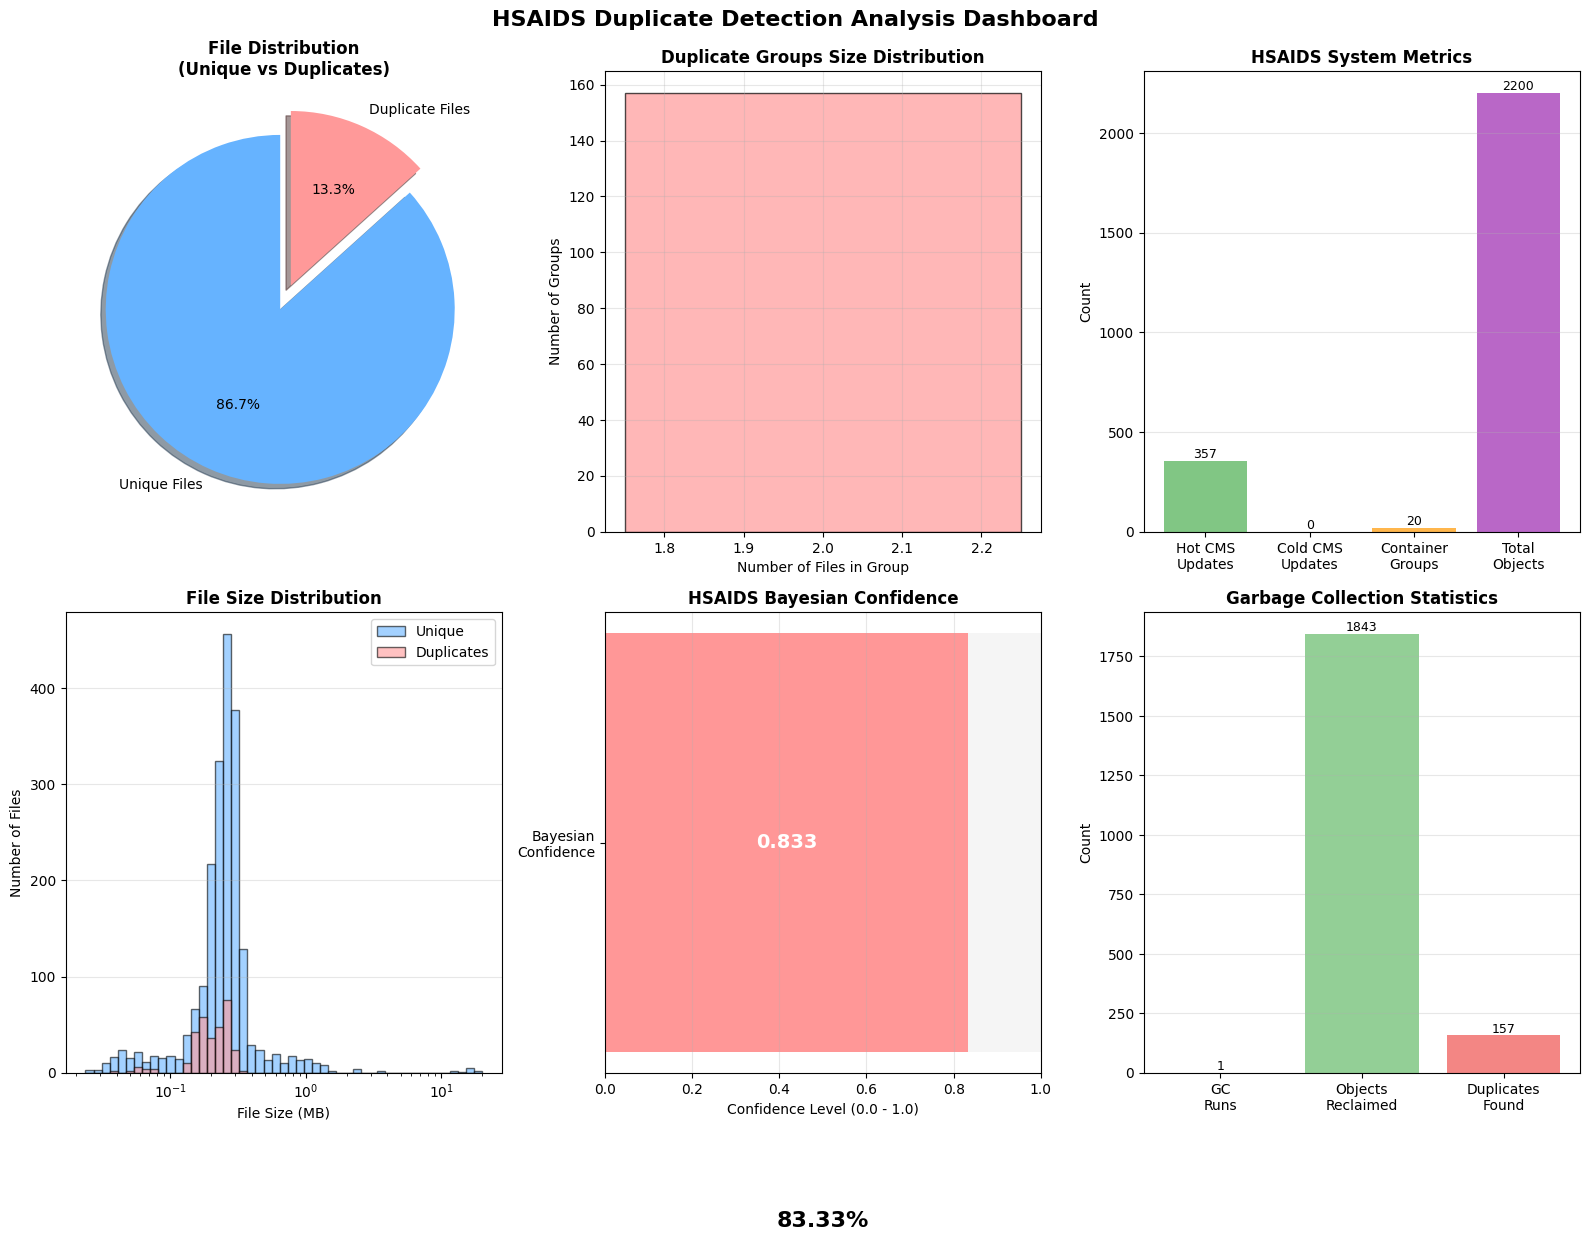


📊 Visualization complete!


In [7]:
# Visualize Results with Graphs
fig = plt.figure(figsize=(16, 12))

# 1. File Distribution Pie Chart - Calculate from file_hash_map
ax1 = plt.subplot(2, 3, 1)
# Count unique files (hashes that appear only once)
unique_count = sum(1 for paths in file_hash_map.values() if len(paths) == 1)
# Count duplicate files (all files in groups with more than one file)
duplicate_count = sum(len(paths) for paths in file_hash_map.values() if len(paths) > 1)

labels = ['Unique Files', 'Duplicate Files']
sizes = [unique_count, duplicate_count]
colors = ['#66b3ff', '#ff9999']
explode = (0.05, 0.1) if duplicate_count > 0 else (0.05, 0)
ax1.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=90)
ax1.set_title('File Distribution\n(Unique vs Duplicates)', fontsize=12, fontweight='bold')

# 2. Duplicate Groups Size Distribution
ax2 = plt.subplot(2, 3, 2)
if duplicate_groups:
    group_sizes = [len(paths) for paths in duplicate_groups.values()]
    if len(set(group_sizes)) > 1:
        # Use appropriate number of bins
        max_size = max(group_sizes)
        num_bins = min(20, max_size, len(set(group_sizes)))
        ax2.hist(group_sizes, bins=num_bins, color='#ff9999', edgecolor='black', alpha=0.7)
    else:
        # If all groups have same size, show a single bar
        ax2.bar(group_sizes[0], len(group_sizes), color='#ff9999', edgecolor='black', alpha=0.7, width=0.5)
    ax2.set_xlabel('Number of Files in Group')
    ax2.set_ylabel('Number of Groups')
    ax2.set_title('Duplicate Groups Size Distribution', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3)
else:
    ax2.text(0.5, 0.5, 'No Duplicate Groups', ha='center', va='center', fontsize=14)
    ax2.set_title('Duplicate Groups Size Distribution', fontsize=12, fontweight='bold')

# 3. HSAIDS Statistics - System Metrics
ax3 = plt.subplot(2, 3, 3)
if stats:
    metrics = ['Hot CMS\nUpdates', 'Cold CMS\nUpdates', 'Container\nGroups', 'Total\nObjects']
    values = [
        stats['hot_cms_updates'],
        stats['cold_cms_updates'],
        stats['container_groups'],
        stats['total_objects']
    ]
    bars = ax3.bar(metrics, values, color=['#4CAF50', '#2196F3', '#FF9800', '#9C27B0'], alpha=0.7)
    ax3.set_ylabel('Count')
    ax3.set_title('HSAIDS System Metrics', fontsize=12, fontweight='bold')
    ax3.grid(True, alpha=0.3, axis='y')
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontsize=9)

# 4. File Size Distribution (Unique vs Duplicates)
ax4 = plt.subplot(2, 3, 4)
if file_hash_map:
    unique_sizes = []
    duplicate_sizes = []
    
    # Get file sizes for unique files (hash appears only once)
    for paths in file_hash_map.values():
        if len(paths) == 1:
            # Unique file
            file_path = paths[0]
            try:
                size_mb = os.path.getsize(file_path) / (1024 * 1024)
                unique_sizes.append(size_mb)
            except:
                pass
        else:
            # Duplicate files (all files in this group)
            for file_path in paths:
                try:
                    size_mb = os.path.getsize(file_path) / (1024 * 1024)
                    duplicate_sizes.append(size_mb)
                except:
                    pass
    
    if unique_sizes or duplicate_sizes:
        # Create appropriate bins for log scale
        all_sizes = unique_sizes + duplicate_sizes
        if all_sizes:
            min_size = max(0.001, min(all_sizes))  # Avoid log(0)
            max_size = max(all_sizes)
            bins = np.logspace(np.log10(min_size), np.log10(max_size), 50)
        else:
            bins = 30
        
        if unique_sizes:
            ax4.hist(unique_sizes, bins=bins, alpha=0.6, label='Unique', color='#66b3ff', edgecolor='black')
        if duplicate_sizes:
            ax4.hist(duplicate_sizes, bins=bins, alpha=0.6, label='Duplicates', color='#ff9999', edgecolor='black')
        ax4.set_xscale('log')
        ax4.set_xlabel('File Size (MB)')
        ax4.set_ylabel('Number of Files')
        ax4.set_title('File Size Distribution', fontsize=12, fontweight='bold')
        ax4.legend()
        ax4.grid(True, alpha=0.3, axis='y')
    else:
        ax4.text(0.5, 0.5, 'No File Size Data', ha='center', va='center', fontsize=14)
        ax4.set_title('File Size Distribution', fontsize=12, fontweight='bold')

# 5. Bayesian Confidence Visualization
ax5 = plt.subplot(2, 3, 5)
if stats and 'bayesian_confidence' in stats:
    confidence = stats['bayesian_confidence']
    # Create a gauge-style visualization
    ax5.barh(['Bayesian\nConfidence'], [confidence], color='#FF6B6B', alpha=0.7, height=0.5)
    ax5.barh(['Bayesian\nConfidence'], [1.0 - confidence], left=[confidence], color='#E0E0E0', alpha=0.3, height=0.5)
    ax5.set_xlim(0, 1)
    ax5.set_xlabel('Confidence Level (0.0 - 1.0)')
    ax5.set_title('HSAIDS Bayesian Confidence', fontsize=12, fontweight='bold')
    # Add text label on the bar
    if confidence > 0.1:
        ax5.text(confidence/2, 0, f'{confidence:.3f}', ha='center', va='center', 
                 fontsize=14, fontweight='bold', color='white')
    else:
        ax5.text(confidence + 0.05, 0, f'{confidence:.3f}', ha='left', va='center', 
                 fontsize=12, fontweight='bold', color='#FF6B6B')
    ax5.grid(True, alpha=0.3, axis='x')
    # Add percentage text
    ax5.text(0.5, -0.3, f'{confidence*100:.2f}%', ha='center', va='top', 
             fontsize=16, fontweight='bold', transform=ax5.transAxes)
else:
    ax5.text(0.5, 0.5, 'No Confidence Data', ha='center', va='center', fontsize=14)
    ax5.set_title('HSAIDS Bayesian Confidence', fontsize=12, fontweight='bold')

# 6. Garbage Collection Statistics
ax6 = plt.subplot(2, 3, 6)
if stats and 'gc_stats' in stats:
    gc_stats = stats['gc_stats']
    categories = ['GC\nRuns', 'Objects\nReclaimed', 'Duplicates\nFound']
    values = [
        gc_stats.get('runs', 0),
        gc_stats.get('objects_reclaimed', 0),
        gc_stats.get('duplicates_found', 0)
    ]
    bars = ax6.bar(categories, values, color=['#FFA726', '#66BB6A', '#EF5350'], alpha=0.7)
    ax6.set_ylabel('Count')
    ax6.set_title('Garbage Collection Statistics', fontsize=12, fontweight='bold')
    ax6.grid(True, alpha=0.3, axis='y')
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax6.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.suptitle('HSAIDS Duplicate Detection Analysis Dashboard', fontsize=16, fontweight='bold', y=1.02)
plt.show()

print("\n📊 Visualization complete!")


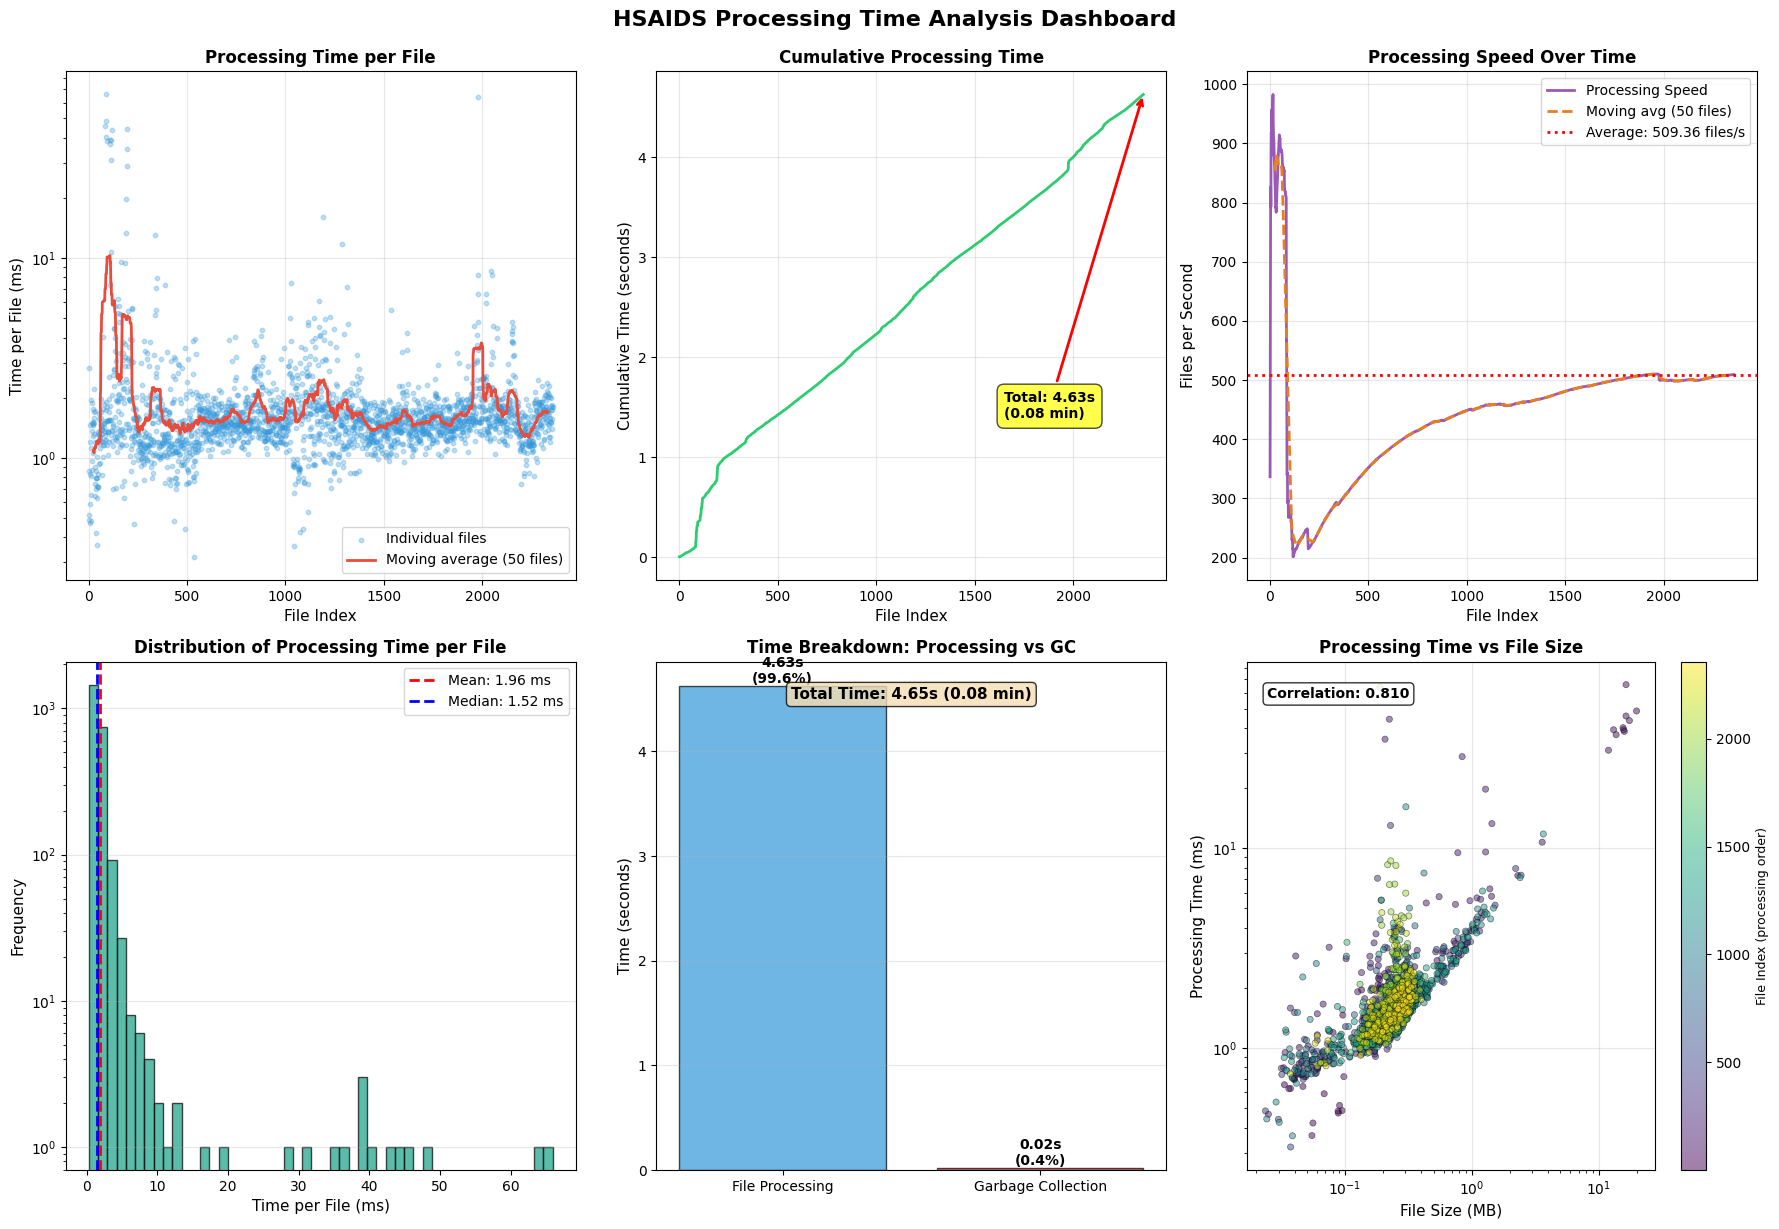


⏱️  TIMING STATISTICS
Total Files Processed: 2357
Total Processing Time: 4.63 seconds (0.08 minutes)
Garbage Collection Time: 0.02 seconds
Total Execution Time: 4.65 seconds (0.08 minutes)

Per-File Statistics:
  Average time per file: 1.96 ms
  Median time per file: 1.52 ms
  Min time per file: 0.32 ms
  Max time per file: 65.95 ms
  Std deviation: 3.43 ms

Processing Speed:
  Average speed: 509.36 files/second
  Peak speed: 982.86 files/second
  Minimum speed: 201.24 files/second

💾 Timing data saved to: timing_analysis.csv


In [8]:
# Timing Analysis and Visualizations
timing_df = pd.DataFrame(timing_data)

# Calculate additional metrics
timing_df['files_per_second'] = timing_df['file_index'] / timing_df['cumulative_time']
timing_df['time_per_file_ms'] = timing_df['time_per_file'] * 1000  # Convert to milliseconds

# Create comprehensive timing visualizations
fig = plt.figure(figsize=(18, 12))

# 1. Time per File (scatter plot with moving average)
ax1 = plt.subplot(2, 3, 1)
ax1.scatter(timing_df['file_index'], timing_df['time_per_file_ms'], 
           alpha=0.3, s=10, color='#3498db', label='Individual files')
# Moving average (window of 50 files)
window = 50
if len(timing_df) > window:
    timing_df['moving_avg'] = timing_df['time_per_file_ms'].rolling(window=window, center=True).mean()
    ax1.plot(timing_df['file_index'], timing_df['moving_avg'], 
            color='#e74c3c', linewidth=2, label=f'Moving average ({window} files)')
ax1.set_xlabel('File Index', fontsize=11)
ax1.set_ylabel('Time per File (ms)', fontsize=11)
ax1.set_title('Processing Time per File', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')  # Log scale for better visualization

# 2. Cumulative Processing Time
ax2 = plt.subplot(2, 3, 2)
ax2.plot(timing_df['file_index'], timing_df['cumulative_time'], 
        color='#2ecc71', linewidth=2)
ax2.set_xlabel('File Index', fontsize=11)
ax2.set_ylabel('Cumulative Time (seconds)', fontsize=11)
ax2.set_title('Cumulative Processing Time', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
# Add annotation for total time
if len(timing_df) > 0:
    total_time = timing_df['cumulative_time'].iloc[-1]
    ax2.annotate(f'Total: {total_time:.2f}s\n({total_time/60:.2f} min)', 
                xy=(len(timing_df), total_time),
                xytext=(len(timing_df)*0.7, total_time*0.3),
                arrowprops=dict(arrowstyle='->', color='red', lw=2),
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7))

# 3. Processing Speed (Files per Second) over Time
ax3 = plt.subplot(2, 3, 3)
ax3.plot(timing_df['file_index'], timing_df['files_per_second'], 
        color='#9b59b6', linewidth=2, label='Processing Speed')
# Moving average for speed
if len(timing_df) > window:
    timing_df['speed_moving_avg'] = timing_df['files_per_second'].rolling(window=window, center=True).mean()
    ax3.plot(timing_df['file_index'], timing_df['speed_moving_avg'], 
            color='#e67e22', linewidth=2, linestyle='--', label=f'Moving avg ({window} files)')
ax3.set_xlabel('File Index', fontsize=11)
ax3.set_ylabel('Files per Second', fontsize=11)
ax3.set_title('Processing Speed Over Time', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)
# Add average speed line
if len(timing_df) > 0:
    avg_speed = timing_df['files_per_second'].iloc[-1]
    ax3.axhline(y=avg_speed, color='r', linestyle=':', linewidth=2, 
               label=f'Average: {avg_speed:.2f} files/s')
    ax3.legend()

# 4. Time Distribution Histogram
ax4 = plt.subplot(2, 3, 4)
ax4.hist(timing_df['time_per_file_ms'], bins=50, color='#16a085', edgecolor='black', alpha=0.7)
ax4.set_xlabel('Time per File (ms)', fontsize=11)
ax4.set_ylabel('Frequency', fontsize=11)
ax4.set_title('Distribution of Processing Time per File', fontsize=12, fontweight='bold')
ax4.set_yscale('log')
ax4.grid(True, alpha=0.3, axis='y')
# Add statistics
mean_time = timing_df['time_per_file_ms'].mean()
median_time = timing_df['time_per_file_ms'].median()
ax4.axvline(mean_time, color='r', linestyle='--', linewidth=2, label=f'Mean: {mean_time:.2f} ms')
ax4.axvline(median_time, color='b', linestyle='--', linewidth=2, label=f'Median: {median_time:.2f} ms')
ax4.legend()

# 5. Time Breakdown (Processing vs GC)
ax5 = plt.subplot(2, 3, 5)
if gc_start_time and gc_end_time:
    gc_time = gc_end_time - gc_start_time
    total_time = total_processing_time + gc_time
    breakdown_data = {
        'File Processing': total_processing_time,
        'Garbage Collection': gc_time
    }
    colors = ['#3498db', '#e74c3c']
    bars = ax5.bar(breakdown_data.keys(), breakdown_data.values(), color=colors, alpha=0.7, edgecolor='black')
    ax5.set_ylabel('Time (seconds)', fontsize=11)
    ax5.set_title('Time Breakdown: Processing vs GC', fontsize=12, fontweight='bold')
    ax5.grid(True, alpha=0.3, axis='y')
    # Add value labels
    for bar, (key, value) in zip(bars, breakdown_data.items()):
        height = bar.get_height()
        percentage = (value / total_time) * 100
        ax5.text(bar.get_x() + bar.get_width()/2., height,
                f'{value:.2f}s\n({percentage:.1f}%)', 
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    # Add total time annotation
    ax5.text(0.5, 0.95, f'Total Time: {total_time:.2f}s ({total_time/60:.2f} min)', 
            transform=ax5.transAxes, ha='center', va='top',
            fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# 6. Processing Speed by File Size (if correlation exists)
ax6 = plt.subplot(2, 3, 6)
scatter = ax6.scatter(timing_df['file_size_mb'], timing_df['time_per_file_ms'], 
                     c=timing_df['file_index'], cmap='viridis', 
                     alpha=0.5, s=20, edgecolors='black', linewidth=0.5)
ax6.set_xlabel('File Size (MB)', fontsize=11)
ax6.set_ylabel('Processing Time (ms)', fontsize=11)
ax6.set_title('Processing Time vs File Size', fontsize=12, fontweight='bold')
ax6.set_xscale('log')
ax6.set_yscale('log')
ax6.grid(True, alpha=0.3)
# Add colorbar
cbar = plt.colorbar(scatter, ax=ax6)
cbar.set_label('File Index (processing order)', fontsize=9)
# Add correlation coefficient
correlation = np.corrcoef(timing_df['file_size_mb'], timing_df['time_per_file_ms'])[0, 1]
ax6.text(0.05, 0.95, f'Correlation: {correlation:.3f}', 
        transform=ax6.transAxes, ha='left', va='top',
        fontsize=10, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.suptitle('HSAIDS Processing Time Analysis Dashboard', fontsize=16, fontweight='bold', y=1.02)
plt.show()

# Print timing statistics
print("\n⏱️  TIMING STATISTICS")
print("=" * 60)
print(f"Total Files Processed: {len(timing_df)}")
print(f"Total Processing Time: {total_processing_time:.2f} seconds ({total_processing_time/60:.2f} minutes)")
if gc_start_time and gc_end_time:
    print(f"Garbage Collection Time: {gc_time:.2f} seconds")
    print(f"Total Execution Time: {total_time:.2f} seconds ({total_time/60:.2f} minutes)")
print("\nPer-File Statistics:")
print(f"  Average time per file: {timing_df['time_per_file_ms'].mean():.2f} ms")
print(f"  Median time per file: {timing_df['time_per_file_ms'].median():.2f} ms")
print(f"  Min time per file: {timing_df['time_per_file_ms'].min():.2f} ms")
print(f"  Max time per file: {timing_df['time_per_file_ms'].max():.2f} ms")
print(f"  Std deviation: {timing_df['time_per_file_ms'].std():.2f} ms")
print(f"\nProcessing Speed:")
print(f"  Average speed: {timing_df['files_per_second'].iloc[-1]:.2f} files/second")
print(f"  Peak speed: {timing_df['files_per_second'].max():.2f} files/second")
print(f"  Minimum speed: {timing_df['files_per_second'].min():.2f} files/second")

# Save timing data to CSV
timing_df.to_csv("timing_analysis.csv", index=False)
print(f"\n💾 Timing data saved to: timing_analysis.csv")
